<a href="https://colab.research.google.com/github/kurkur19/NLP_al_khmuz/blob/main/Al_Khmuz_NLP_7lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Аль Хмуз Карина Бассамівна БС-25
Практична робота №7

ГЕНЕРАЦІЯ ІМЕН ЗА ДОПОМОГОЮ РЕКУРЕНТНИХ НЕЙРОННИХ МЕРЕЖ (RNN)











In [4]:
from google.colab import files
uploaded = files.upload()

Saving names.txt to names.txt


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib.pyplot as plt
import numpy as np
from random import sample
import os

# Завантаження даних
file_path = "names.txt"
with open(file_path, "r", encoding="utf-8") as f:
    names = f.read().splitlines()

eos_token = "*"
names = [' ' + name + eos_token for name in names]

unique_chars = sorted(set("".join(names)))
char_to_id = {char: idx + 1 for idx, char in enumerate(unique_chars)}
id_to_char = {idx: char for char, idx in char_to_id.items()}
vocab_size = len(char_to_id)
name_lengths = [len(name) for name in names]

def to_matrix(data, token_dict, max_len=None, dtype="int32", batch_first=True):
    max_len = max_len or max(map(len, data))
    data_ix = np.zeros((len(data), max_len), dtype=dtype) + token_dict[" "]
    for i, name in enumerate(data):
        line_ix = [token_dict[c] for c in name]
        data_ix[i, :len(line_ix)] = line_ix
    if not batch_first:
        data_ix = np.transpose(data_ix)
    return data_ix

# Клас для ручної RNN
class CharRNNCell(nn.Module):
    def __init__(self, num_tokens, embedding_size=16, rnn_num_units=64):
        super().__init__()
        self.num_units = rnn_num_units
        self.embedding = nn.Embedding(num_tokens, embedding_size)
        self.rnn_update = nn.Linear(embedding_size + rnn_num_units, rnn_num_units)
        self.rnn_to_logits = nn.Linear(rnn_num_units, num_tokens)

    def forward(self, x, h_prev):
        x_emb = self.embedding(x)
        x_and_h = torch.cat([x_emb, h_prev], dim=1)
        h_next = self.rnn_update(x_and_h)
        h_next = torch.tanh(h_next)
        logits = self.rnn_to_logits(h_next)
        return h_next, F.log_softmax(logits, dim=-1)

    def initial_state(self, batch_size):
        return Variable(torch.zeros(batch_size, self.num_units))

def rnn_loop(rnn, batch_index):
    batch_size, max_length = batch_index.size()
    hid_state = rnn.initial_state(batch_size)
    logprobs = []
    for x_t in batch_index.transpose(0, 1):
        hid_state, logp_next = rnn(x_t, hid_state)
        logprobs.append(logp_next)
    return torch.stack(logprobs, dim=1)

def generate_sample(rnn, seed_phrase=" ", max_length=20, temperature=1.0):
    if not seed_phrase: seed_phrase = " "
    x_sequence = [char_to_id.get(token, char_to_id[" "]) for token in seed_phrase]
    x_sequence = torch.tensor([x_sequence], dtype=torch.int64)
    hid_state = rnn.initial_state(batch_size=1)
    if hid_state.size(1) != rnn.num_units: hid_state = torch.zeros(1, rnn.num_units)

    for t in range(len(seed_phrase) - 1):
        _, hid_state = rnn(x_sequence[:, t], hid_state)
        if hid_state.size(1) != rnn.num_units: hid_state = torch.zeros(1, rnn.num_units)

    for _ in range(max_length - len(seed_phrase)):
        _, logp_next = rnn(x_sequence[:, -1], hid_state)
        p_next = torch.softmax(logp_next / temperature, dim=-1).data.numpy()[0]
        next_ix = np.random.choice(len(p_next), p=p_next)
        x_sequence = torch.cat([x_sequence, torch.tensor([[next_ix]])], dim=1)
        if id_to_char.get(next_ix) == eos_token or id_to_char.get(next_ix) == ' ': break

    return "".join([id_to_char.get(ix, " ") for ix in x_sequence.data.numpy()[0] if (ix and id_to_char[ix] != eos_token)])



Починаємо навчання ручної RNN...


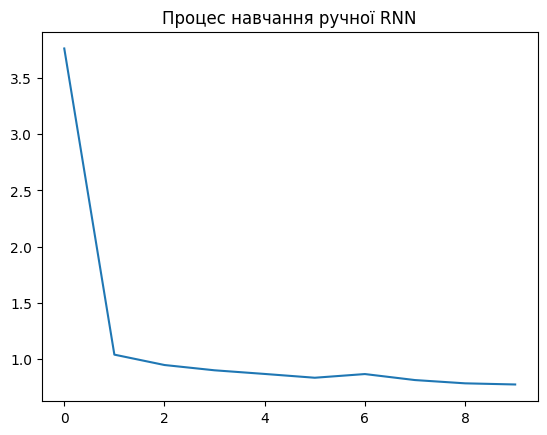


Згенеровані імена (Ручна RNN):

Температура 0.01:
Abaninininininininin
Abaninininininininin
Abaninininininininin
Abaninininininininin
Abaninininininininin

Температура 0.2:
Abaninininov
Aban
Abanyaninininininyan
Abanov
Abanininov

Температура 0.5:
Abev
Abachov
Abankhevinyankofffff
Abugalevevinyanov
Abanevskovaganyarybe

Температура 1.0:
Abajanyantshin
Abrov
Abutov
Abalybashedinrychfff
Abikv

Температура 2.0:
AbJowzhRbupbolskyUkc
AbEnufYarRevypiDoric
AbayJI
AbihphUch-zUcheviara
Aba'nkhy


In [6]:
# Навчання
num_tokens = vocab_size + 1
char_rnn = CharRNNCell(num_tokens=num_tokens, embedding_size=128, rnn_num_units=128)
opt = torch.optim.Adam(char_rnn.parameters())
history = []
MAX_LENGTH = max(name_lengths)

print("Починаємо навчання ручної RNN...")
for i in range(1000): # Зменшено для швидкості демонстрації, в оригіналі 10000
    batch_names = sample(names, min(32, len(names)))
    batch_ix = to_matrix(batch_names, char_to_id, max_len=MAX_LENGTH)
    batch_ix = torch.tensor(batch_ix, dtype=torch.int64)

    logp_seq = rnn_loop(char_rnn, batch_ix)
    predictions_logp = logp_seq[:, :-1]
    actual_next_tokens = batch_ix[:, 1:]
    loss = -torch.mean(torch.gather(predictions_logp, dim=2, index=actual_next_tokens[:, :, None]))

    loss.backward()
    opt.step()
    opt.zero_grad()

    if i % 100 == 0:
        history.append(loss.item())

plt.plot(history, label="Training Loss")
plt.title("Процес навчання ручної RNN")
plt.show()

print("\nЗгенеровані імена (Ручна RNN):")
for temp in [0.01, 0.2, 0.5, 1.0, 2.0]:
    print(f"\nТемпература {temp}:")
    for _ in range(5):
        print(generate_sample(char_rnn, seed_phrase="Ab", temperature=temp))

Починаємо навчання nn.RNN...


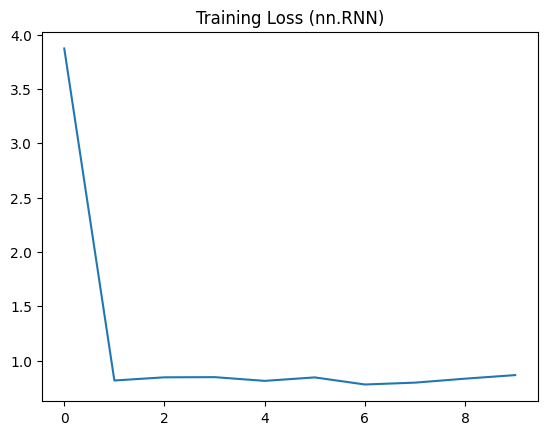


Generated Names (nn.RNN):

Температура 0.01:
Arov
Arov
Arov
Arov
Arov

Температура 0.2:
Arov
Arov
Arov
Arov
Arov

Температура 0.5:
Arov
Arov
Arov
Arov
Arov

Температура 1.0:
Aroshekin
Aronok
Arovska
Arovikin
Aroff

Температура 2.0:
Aritzr
Arozmutspain
Arovirjnovskl
AryaevlelodOt
Arov


In [7]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        logits = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, 128)

def generate_sample_nn(model, seed_phrase=" ", max_len=20, temperature=1.0):
    model.eval()
    x_sequence = [char_to_id.get(token, char_to_id[" "]) for token in seed_phrase]
    x_sequence = torch.tensor([x_sequence], dtype=torch.int64)
    hidden = model.init_hidden(batch_size=1)

    for _ in range(max_len - len(seed_phrase)):
        logits, hidden = model(x_sequence[:, -1:], hidden)
        probs = torch.softmax(logits / temperature, dim=-1).data.numpy()[0, -1]
        next_ix = np.random.choice(len(probs), p=probs)
        x_sequence = torch.cat([x_sequence, torch.tensor([[next_ix]])], dim=1)
        if id_to_char.get(next_ix) == eos_token or id_to_char.get(next_ix) == '': break

    return "".join([id_to_char[ix] for ix in x_sequence.data.numpy()[0] if id_to_char[ix] != eos_token])

model = CharRNN(vocab_size=vocab_size + 1, embedding_dim=128, hidden_dim=128)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
names_matrix = to_matrix(names, char_to_id)

history_nn = []
print("Починаємо навчання nn.RNN...")
for epoch in range(1000): # Зменшено для швидкості демонстрації
    model.train()
    batch_indices = sample(range(len(names)), min(32, len(names)))
    batch_x = names_matrix[batch_indices, :-1]
    batch_y = names_matrix[batch_indices, 1:]

    hidden = model.init_hidden(min(32, len(names)))
    logits, _ = model(torch.tensor(batch_x, dtype=torch.int64), hidden)
    loss = criterion(logits.view(-1, vocab_size + 1), torch.tensor(batch_y, dtype=torch.int64).view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        history_nn.append(loss.item())

plt.plot(history_nn)
plt.title("Training Loss (nn.RNN)")
plt.show()

print("\nGenerated Names (nn.RNN):")
for temp in [0.01, 0.2, 0.5, 1.0, 2.0]:
    print(f"\nТемпература {temp}:")
    for _ in range(5):
        print(generate_sample_nn(model, seed_phrase="Ar", temperature=temp))

**Опис результатів для ручної RNN та nn.RNN**

***Аналіз графіків втрат (Training Loss)***

Обидва графіки демонструють різке стрімке падіння значення помилки на початкових етапах навчання. Це свідчить про те, що моделі швидко засвоюють базові закономірності в текстових даних.

Після стрімкого падіння криві вирівнюються та стабілізуються (на рівні близько 0.8–1.0), що є чіткою ознакою успішної збіжності нейронних мереж.

Графік вбудованої архітектури nn.RNN виглядає дещо стабільнішим на пізніх епохах, оскільки ця модель використовує оптимізовані внутрішні обчислення.

***Аналіз згенерованих імен та впливу температури***

При низьких температурах (0.01, 0.2, 0.5): Моделі поводяться максимально "консервативно", щоразу обираючи літери з найвищою ймовірністю. Через це імена виходять одноманітними, часто зацикленими або повністю ідентичними одне одному (наприклад, суцільне повторення "Arov" або "Abaninin...").

При температурі 1.0: Досягається найкращий баланс між вивченими правилами та випадковістю. Моделі генерують різноманітні, нові імена, які фонетично та структурно схожі на реальні слова із заданого датасету ("Aroshekin", "Abutov").

При високій температурі (2.0): Ступінь випадковості стає занадто великим. Мережа починає обирати малоймовірні символи, що призводить до генерації хаотичного, нечитабельного набору літер без жодного змісту ("Aritzr", "AbJowzhRbupbolskyUkc").

**Контрольні питання**

1.	Що таке рекурентна нейронна мережа (RNN), і як вона використовується для генерації тексту?

Рекурентна нейронна мережа (RNN) — це мережа з "пам'яттю", що враховує послідовність даних шляхом передачі прихованого стану на кожному кроці для посимвольного передбачення наступного символу.

2.	Чому в задачі генерації тексту використовується softmax з температурою? Як температура впливає на результати?

Softmax з температурою використовується для контролю випадковості вибору символів. Низька температура робить генерацію консервативною та передбачуваною, а висока додає хаотичності та різноманітності.

3.	Яка різниця між ручною реалізацією RNN (через CharRNNCell) та використанням вбудованого модуля nn.RNN?

Вбудований модуль nn.RNN оптимізований і автоматично виконує тензорні обчислення та оновлення станів, тоді як у ручній реалізації CharRNNCell конкатенацію та лінійні перетворення потрібно прописувати самостійно.

4.	Що таке EOS-токен (*) і яку роль він відіграє в процесі генерації?

EOS-токен (*) — це спеціальний символ, який позначає завершення послідовності (імені) і є умовою для зупинки генерації тексту.

5.	Які параметри RNN впливають на якість генерації (наприклад, розмір ембеддингів, кількість прихованих шарів, кількість епох)?

На якість впливають розмір векторного представлення символів (embedding_size), кількість нейронів у прихованому стані (hidden_dim), кількість епох навчання та параметр температури.

6.	Чому	в	процесі	навчання	RNN	використовується	функція	втрат CrossEntropyLoss?

Функція CrossEntropyLoss використовується, оскільки передбачення наступного символу є задачею класифікації, і функція мінімізує негативний логарифм ймовірності правильних цільових токенів.

7.	Що означає "hidden state" у RNN, і як він зберігає інформацію про попередні символи?

"Hidden state" (прихований стан) — це внутрішній вектор пам'яті мережі, який оновлюється на кожному кроці шляхом об'єднання поточного вхідного символу та стану з попереднього кроку.

8.	Як можна покращити якість генерації тексту при використанні RNN?

Покращити якість можна оптимізацією гіперпараметрів (кількості епох, hidden_dim), розширенням словника та датасету, або переходом на складніші архітектури, такі як LSTM, GRU чи Трансформери.

9.	Що відбувається, якщо навчати RNN із занадто малим або занадто великим розміром ембеддингів?

Занадто малий розмір ембеддингів перешкоджатиме мережі знаходити складні закономірності між символами, а занадто великий — призведе до швидкого перенавчання (overfitting) та сповільнить розрахунки.

10.	Які проблеми виникають при навчанні RNN, і як їх можна вирішити (наприклад, проблема затухаючих градієнтів)?

Основна проблема — затухаючі або вибухаючі градієнти, через які мережа "забуває" інформацію з початку довгих послідовностей. Вирішується застосуванням обрізання градієнтів (gradient clipping) або використанням модифікованих комірок LSTM/GRU.
